# Spectral Trajectory Clustering (Stage 2)

Mirrors the week-9 ML4BD spectral pipeline on Lernnavi's 12-week behavioural sequences.

**Two time-series strategies** (week-9 demo, generalised to multivariate features):
1. **Aggregated** — average each feature over the 12 weeks, then RBF similarity
2. **Fixed-interval Euclidean** — per-sequence L2-normalise (shape over level), flatten, RBF similarity

**Matched baseline** — K-Means on the flattened (non-normalised) sequence vector for the same subsample, so the comparison is method-vs-method rather than method-vs-sample-size.

**Design choices**
- `is_dropout_point` is used only for post-hoc interpretation, never as a clustering feature.
- Subsample is **stratified on `is_dropout_point`** so the minority class isn't randomly thinned.
- Same `random_state` and same subsample indices across all four methods so the spectral and K-Means partitions cluster the exact same sequences.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import linalg
from scipy.sparse.csgraph import laplacian

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.manifold import spectral_embedding
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Configuration

Spectral clustering scales O(n²) in memory and O(n³) in eigendecomposition. We **subsample to 5 000 sequences** stratified on `is_dropout_point` — enough to recover archetypes (week-9 used 30 students) while keeping the eigendecomposition tractable.


In [2]:
@dataclass(frozen=True)
class Config:
    project_dir: Path = Path.cwd()
    data_dir: Path = Path("data")
    output_dir: Path = Path("outputs")
    random_state: int = RANDOM_STATE

    sequence_length: int = 12
    k_min: int = 2
    k_max: int = 8

    # Spectral subsample (shared across the 2 spectral methods + K-Means baseline)
    sample_size: int = 7500

    # Pre-selected k for each method (revisit after looking at diagnostics)
    aggregated_k: int = 4
    euclidean_k: int = 4

    # RBF gamma is scaled by 1/n_features inside `rbf_similarity` so the kernel
    # doesn't saturate to zero on multivariate / flattened-sequence inputs.
    rbf_base_gamma: float = 1.0

    save_outputs: bool = True


CFG = Config()
CFG.output_dir.mkdir(exist_ok=True, parents=True)
CFG

Config(project_dir=WindowsPath('c:/Users/loicm/Documents/EPFL/2025-2026/MA4/ML_for_BD/CS-421-Project-learnavi'), data_dir=WindowsPath('data'), output_dir=WindowsPath('outputs'), random_state=42, sequence_length=12, k_min=2, k_max=8, sample_size=7500, aggregated_k=4, euclidean_k=4, rbf_base_gamma=1.0, save_outputs=True)

## 2. Spectral Clustering Helpers

Lifted from the week-9 demo notebook. The non-trivial bit is `spectral_clustering`: normalized Laplacian → spectral embedding → KMeans on the embedded coordinates. The sorted eigenvalues are returned so we can plot the **eigengap** heuristic alongside silhouette.


In [3]:
def get_adjacency(S, connectivity="full"):
    """Adjacency matrix from a similarity matrix. 'full' returns S, 'epsilon' thresholds at 0.5."""
    if connectivity == "full":
        return S
    if connectivity == "epsilon":
        return np.where(S > 0.5, 1, 0)
    raise RuntimeError(f"connectivity '{connectivity}' not supported")


def spectral_clustering(W, n_clusters, random_state=RANDOM_STATE):
    """
    Normalized Laplacian + spectral embedding + KMeans on the embedded coords.
    Returns (kmeans, embedding, sorted_eigenvalues).
    """
    L = laplacian(W, normed=True)
    eigenvals, _ = linalg.eig(L)
    eigenvals = np.real(eigenvals)
    eigenvals_sorted = eigenvals[np.argsort(eigenvals)]

    rs = np.random.RandomState(random_state)
    proj_X = spectral_embedding(W, n_components=n_clusters, random_state=rs, drop_first=False)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(proj_X)
    return kmeans, proj_X, eigenvals_sorted


In [4]:
def plot_metrics(n_clusters_list, metric_dictionary, title=""):
    """Two panels: silhouette score vs k, and sorted eigenvalues (for eigengap)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    n_show = max(len(list(n_clusters_list)) * 2, 6)

    axes[0].plot(list(n_clusters_list), metric_dictionary["Silhouette"], "-o", color="#2563eb")
    axes[0].set_xlabel("Number of clusters")
    axes[0].set_ylabel("Silhouette")
    axes[0].set_xticks(list(n_clusters_list))
    axes[0].set_title("Silhouette")

    eig = metric_dictionary["Eigengap"][:n_show]
    axes[1].scatter(range(1, len(eig) + 1), eig, color="#dc2626")
    axes[1].set_xlabel("Eigenvalue index")
    axes[1].set_ylabel("Eigenvalue")
    axes[1].set_xticks(range(1, len(eig) + 1))
    axes[1].set_title("Eigengap")

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def get_heuristics_spectral(W, n_clusters_list, title="", plot=True, random_state=RANDOM_STATE):
    """Runs spectral clustering for each k and records silhouette on the embedded points."""
    silhouette_list = []
    df_labels = pd.DataFrame()
    eigenvals_sorted = None

    for k in n_clusters_list:
        kmeans, proj_X, eigenvals_sorted = spectral_clustering(W, k, random_state=random_state)
        labels = kmeans.labels_
        df_labels[str(k)] = labels
        silhouette_list.append(np.nan if k == 1 else silhouette_score(proj_X, labels))

    metric_dictionary = {"Silhouette": silhouette_list, "Eigengap": eigenvals_sorted}
    if plot:
        plot_metrics(n_clusters_list, metric_dictionary, title=title)
        return df_labels
    return df_labels, metric_dictionary


## 3. Similarity Helpers for Multivariate Sequences

Two pieces:
- `rbf_similarity` — RBF kernel with `gamma` scaled by `1/n_features`.
- `per_sequence_l2_normalize` — normalises each (sequence, feature) row so spectral picks up shape over level.


In [5]:
def rbf_similarity(X, base_gamma=1.0):
    gamma = base_gamma / max(X.shape[1], 1)
    return pairwise_kernels(X, metric="rbf", gamma=gamma)


def per_sequence_l2_normalize(X_seq):
    """
    L2-normalise each (sequence, feature) row.
    Equivalent to week-9's per-row normalisation, applied independently per feature
    on multivariate sequences so cross-feature scale is preserved.
    """
    norms = np.linalg.norm(X_seq, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X_seq / norms

## 4. Shared Preprocessing and Summary Helpers

Lifted from `clustering_v2.ipynb` so this notebook is self-contained.


In [6]:
def preprocessing_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])


def preprocess_features(df, feature_cols):
    pipe = preprocessing_pipeline()
    X = pipe.fit_transform(df[feature_cols])
    return X, pipe


def trajectory_overview(traj_df, cluster_col, id_col="user_id", label_col="is_dropout_point"):
    overview = (
        traj_df.groupby(cluster_col)
        .agg(
            n_sequences=(id_col, "count"),
            n_users=(id_col, "nunique"),
            interruption_rate=(label_col, "mean"),
        )
        .reset_index()
    )
    overview["share_sequences"] = overview["n_sequences"] / overview["n_sequences"].sum()
    return overview


def trajectory_dimension_curves(X_sequences, feature_cols, feature_groups):
    curves = {}
    for group_name, cols in feature_groups.items():
        indices = [feature_cols.index(c) for c in cols if c in feature_cols]
        if indices:
            curves[group_name] = X_sequences[:, :, indices].mean(axis=2)
    return curves


def plot_trajectory_profiles(X_seq, labels, feature_cols, feature_groups, title):
    curves = trajectory_dimension_curves(X_seq, feature_cols, feature_groups)
    n = len(curves)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, (dim, values) in zip(axes, curves.items()):
        for cluster_id in sorted(np.unique(labels)):
            mask = labels == cluster_id
            ax.plot(values[mask].mean(axis=0), marker="o", label=f"C{cluster_id}")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(dim)
        ax.set_xlabel("Week")
    axes[0].set_ylabel("Avg standardized score")
    axes[-1].legend(loc="best", fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## 5. Build 12-Week Sequences

Rebuilds the same trajectory tensor as `clustering_v2.ipynb`. Calendar variables (`year`, `day`) are excluded so we don't cluster mostly on seasonality.


In [7]:
def build_sequences(df, feature_cols, *, id_col, time_col, label_col, sequence_length):
    df = df.sort_values([id_col, time_col]).dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

    X_weekly, _ = preprocess_features(df, feature_cols)
    y_all = df[label_col].to_numpy()
    weeks_all = df[time_col].to_numpy()
    index_all = df.index.to_numpy()

    X_sequences, y_sequences, metadata_rows = [], [], []
    for user_id, user_idx in df.groupby(id_col).indices.items():
        user_idx = np.asarray(user_idx)
        if len(user_idx) < sequence_length:
            continue
        for end_pos in range(sequence_length - 1, len(user_idx)):
            seq_positions = user_idx[end_pos - sequence_length + 1:end_pos + 1]
            end_position = user_idx[end_pos]
            X_sequences.append(X_weekly[seq_positions])
            y_sequences.append(int(y_all[end_position]))
            metadata_rows.append({
                id_col: user_id,
                "end_week": weeks_all[end_position],
                "row_index": index_all[end_position],
                label_col: int(y_all[end_position]),
            })

    return np.asarray(X_sequences), np.asarray(y_sequences), pd.DataFrame(metadata_rows)


In [8]:
import preprocess as preprocess_module

_, _, _, _, feature_cols, df_full = preprocess_module.preprocess(CFG.data_dir)

stage2_behavior_features = [c for c in feature_cols if c not in {"year", "day"}]
STAGE2_ID = "user_id"
STAGE2_TIME = "relative_week"
STAGE2_LABEL = "is_dropout_point"

X_seq, y_seq, traj_df = build_sequences(
    df_full,
    stage2_behavior_features,
    id_col=STAGE2_ID,
    time_col=STAGE2_TIME,
    label_col=STAGE2_LABEL,
    sequence_length=CFG.sequence_length,
)
print("Full sequence tensor:", X_seq.shape)
print("Full interruption rate:", y_seq.mean().round(3))


Full sequence tensor: (222739, 12, 15)
Full interruption rate: 0.497


## 6. Stratified Subsample

Same indices reused across all four methods. Stratifying on `is_dropout_point` keeps the minority class' proportion stable.


In [9]:
n_seq = X_seq.shape[0]
n_sample = min(CFG.sample_size, n_seq)
if n_sample < n_seq:
    sample_idx, _ = train_test_split(
        np.arange(n_seq),
        train_size=n_sample,
        stratify=y_seq,
        random_state=CFG.random_state,
    )
else:
    sample_idx = np.arange(n_seq)
sample_idx = np.sort(sample_idx)

X_seq_s = X_seq[sample_idx]
y_seq_s = y_seq[sample_idx]
traj_df_s = traj_df.iloc[sample_idx].reset_index(drop=True).copy()

print("Subsample shape:", X_seq_s.shape)
print("Subsample interruption rate:", y_seq_s.mean().round(3))


Subsample shape: (7500, 12, 15)
Subsample interruption rate: 0.497


## 7. Strategy A — Aggregated Features

Average each behavioural feature over the 12 weeks, then RBF similarity. This collapses temporal information entirely — useful as a baseline to see what's lost vs the time-aware strategies.


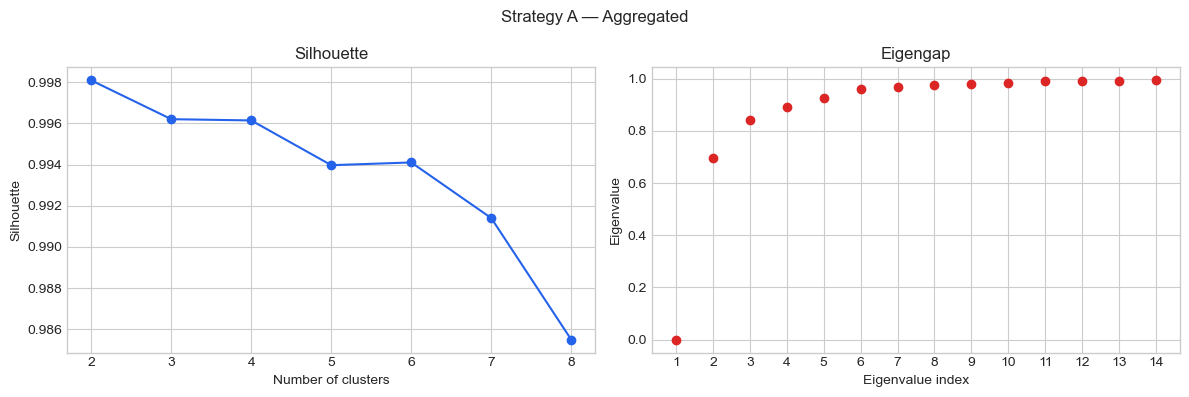

In [10]:
X_agg = X_seq_s.mean(axis=1)  # (n_sequences, n_features)
S_agg = rbf_similarity(X_agg, base_gamma=CFG.rbf_base_gamma)
W_agg = get_adjacency(S_agg, connectivity="full")

n_cluster_list = range(CFG.k_min, CFG.k_max + 1)
df_labels_agg = get_heuristics_spectral(W_agg, n_cluster_list, title="Strategy A — Aggregated")


In [11]:
k_agg = CFG.aggregated_k
traj_df_s["spectral_agg"] = df_labels_agg[str(k_agg)].values
trajectory_overview(traj_df_s, "spectral_agg")


,spectral_agg,n_sequences,n_users,interruption_rate,share_sequences
0,0,7491,4374,0.497130,0.998800
1,1,3,2,0.666667,0.000400
2,2,5,5,0.400000,0.000667
3,3,1,1,0.000000,0.000133


## 8. Strategy B — Fixed-interval Euclidean

Per-sequence L2 normalisation (shape over level), flatten to `(n_sequences, 12·n_features)`, then RBF similarity. Captures the *shape* of weekly trajectories but cannot align peaks that occur in different weeks.

For each sequence $i$ and feature $j$, normalise the length-$T$ vector to unit L2 so each feature's trajectory lives on the unit sphere:

$$
\tilde{x}_{i,t,j} \;=\; \frac{x_{i,t,j}}{\sqrt{\sum_{s=1}^{T} x_{i,s,j}^{\,2}}}.
$$

Flatten $\tilde{X}_i \in \mathbb{R}^{T \times d}$ row-major into $v_i = \mathrm{vec}(\tilde{X}_i) \in \mathbb{R}^{Td}$ and apply the Gaussian kernel:

$$
S^B_{ij} \;=\; \exp\!\big(-\gamma\, \|v_i - v_j\|_2^2\big), \qquad \gamma = \gamma_0 / (Td).
$$



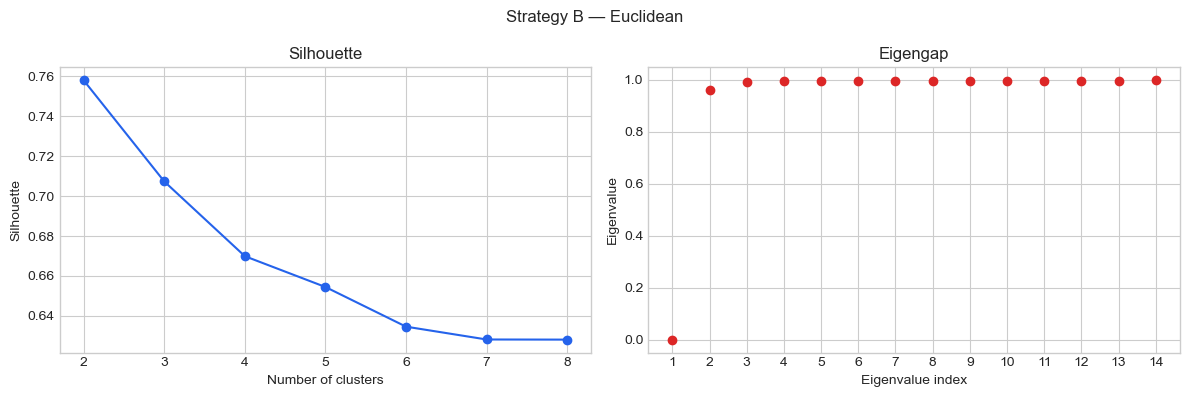

In [12]:
X_seq_norm = per_sequence_l2_normalize(X_seq_s)
X_flat = X_seq_norm.reshape(X_seq_norm.shape[0], -1)
S_eucl = rbf_similarity(X_flat, base_gamma=CFG.rbf_base_gamma)
W_eucl = get_adjacency(S_eucl, connectivity="full")
df_labels_eucl = get_heuristics_spectral(W_eucl, n_cluster_list, title="Strategy B — Euclidean")


In [13]:
k_eucl = CFG.euclidean_k
traj_df_s["spectral_eucl"] = df_labels_eucl[str(k_eucl)].values
trajectory_overview(traj_df_s, "spectral_eucl")


,spectral_eucl,n_sequences,n_users,interruption_rate,share_sequences
0,0,4472,2983,0.536225,0.596267
1,1,954,841,0.443396,0.127200
2,2,607,589,0.485997,0.080933
3,3,1467,1197,0.417178,0.195600


## 9. Matched K-Means Baselines

Two K-Means baselines on the **same subsample** as the spectral methods. Same `k = CFG.euclidean_k` for an apples-to-apples partition count.

- **`kmeans_flat`** — raw flattened sequence vector $v_i = \mathrm{vec}(X_i) \in \mathbb{R}^{Td}$. Matches `clustering_v2.ipynb` §9; eliminates the sample-vs-full confound when comparing against it.
- **`kmeans_eucl`** — L2-normalised + flattened, the **same input representation as Strategy B**. Isolates *what spectral adds over plain k-means on that representation* — both see the identical feature vectors, only the algorithm differs.


In [14]:
X_traj_flat_raw = X_seq_s.reshape(X_seq_s.shape[0], -1)
kmeans_traj = KMeans(n_clusters=CFG.euclidean_k, random_state=CFG.random_state, n_init=10).fit(X_traj_flat_raw)
traj_df_s["kmeans_flat"] = kmeans_traj.labels_
trajectory_overview(traj_df_s, "kmeans_flat")


,kmeans_flat,n_sequences,n_users,interruption_rate,share_sequences
0,0,522,505,0.454023,0.069600
1,1,5883,3680,0.525582,0.784400
2,2,161,131,0.142857,0.021467
3,3,934,775,0.402570,0.124533


### K-Means on Strategy-B features (same L2-normalised flattened vectors as spectral B)

Reuses `X_flat` from §8 (per-sequence L2-normalised, then flattened). Because every $v_i$ has $\|v_i\| = \sqrt{d}$, Euclidean distance on these vectors is monotone in the average per-feature cosine similarity — so this is effectively *spherical k-means* on trajectory shapes.


In [15]:
# Same features as Strategy B (per-sequence L2-normalised, flattened).
# Same k as spectral_eucl so the comparison is apples-to-apples.
kmeans_eucl_model = KMeans(
    n_clusters=4, #CFG.euclidean_k,
    random_state=CFG.random_state,
    n_init=10,
).fit(X_flat)
traj_df_s["kmeans_eucl"] = kmeans_eucl_model.labels_
trajectory_overview(traj_df_s, "kmeans_eucl")

,kmeans_eucl,n_sequences,n_users,interruption_rate,share_sequences
0,0,4255,2842,0.538190,0.567333
1,1,1213,953,0.378401,0.161733
2,2,591,571,0.492386,0.078800
3,3,1441,1152,0.477446,0.192133


## 10. Weekly Dimension Profiles per Method

For each method, plot the average standardised weekly score in four behavioural dimensions (activity, regularity, performance, breadth) per cluster. This is how `clustering_v2.ipynb` §9 interprets clusters; reusing it here so the spectral solutions can be compared on the same axes.


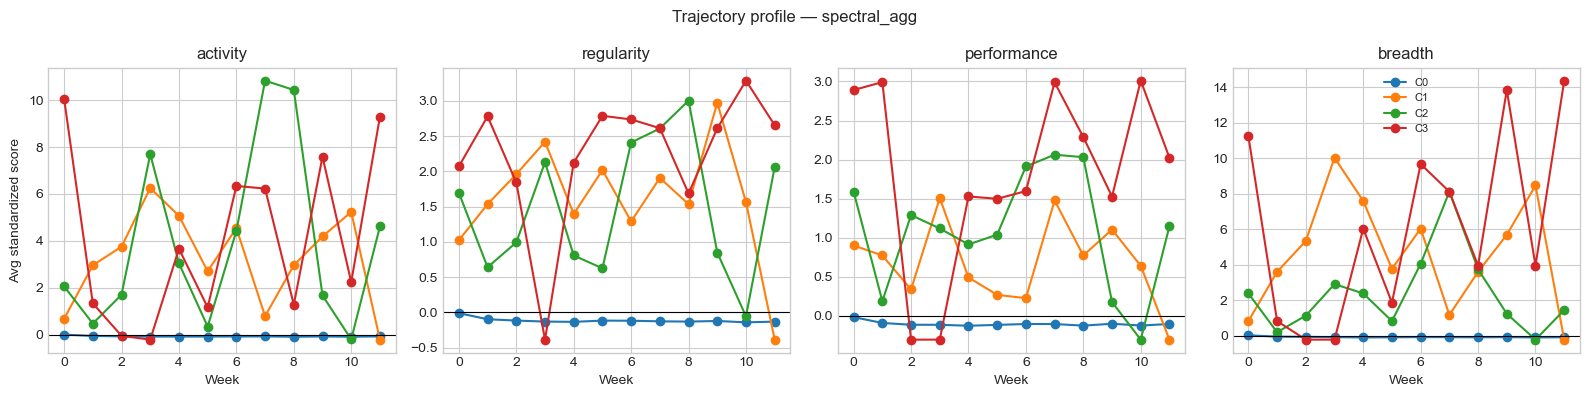

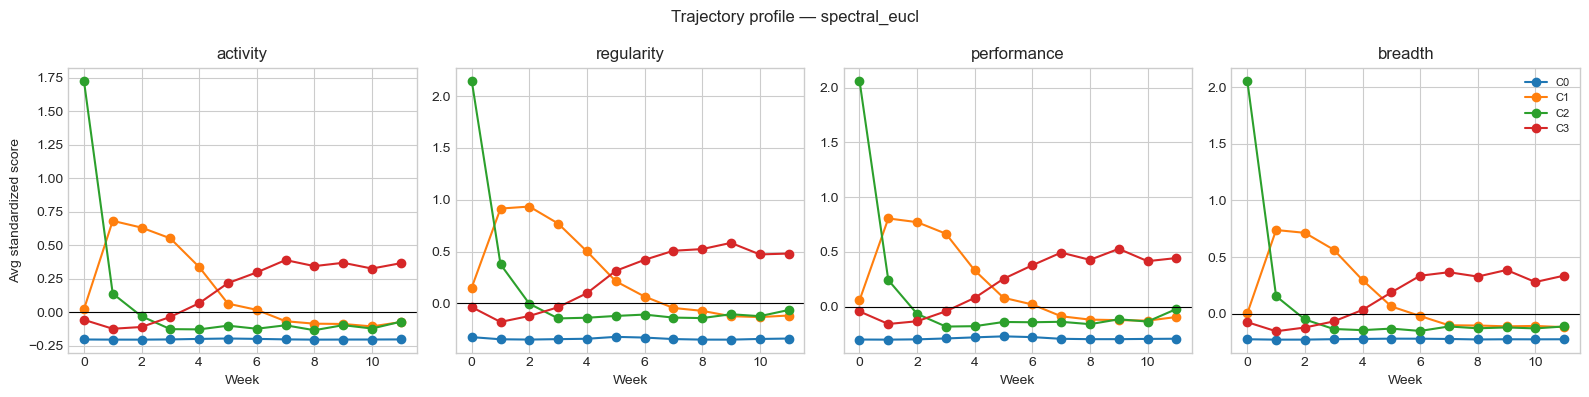

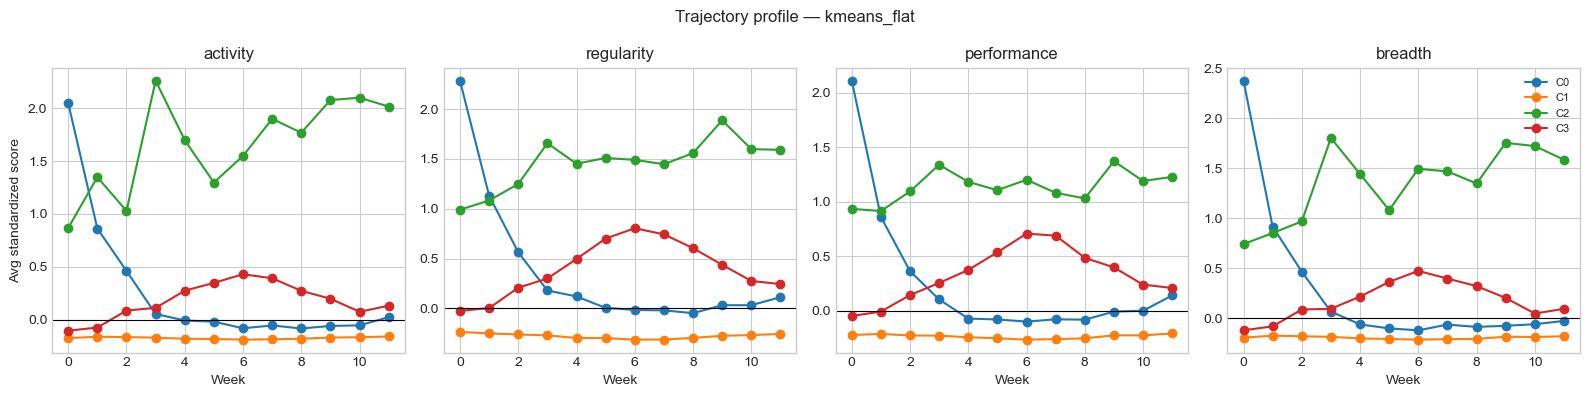

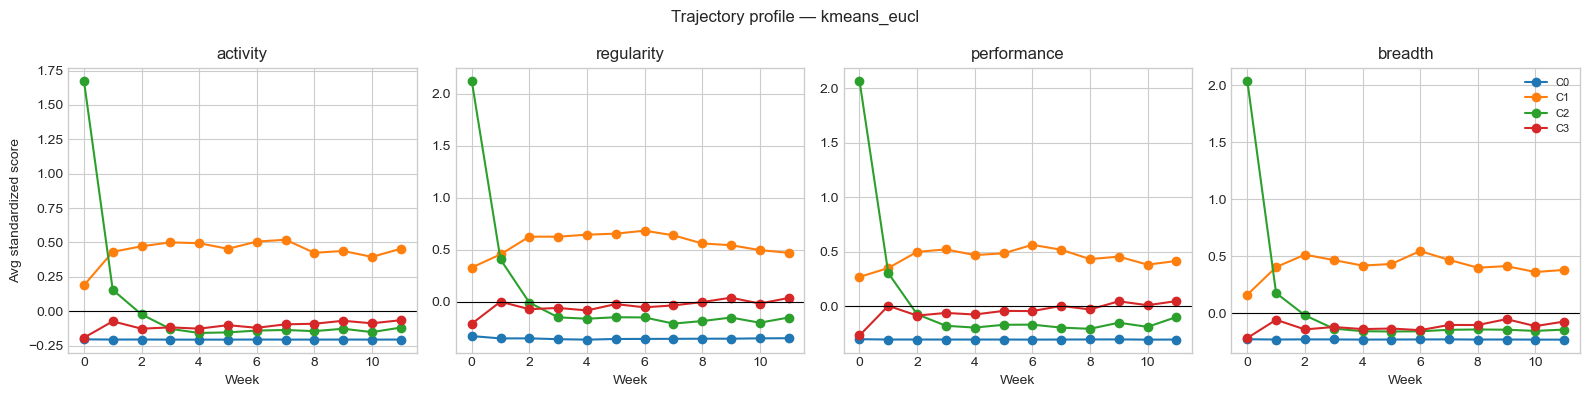

In [16]:
methods = ["spectral_agg", "spectral_eucl", "kmeans_flat", "kmeans_eucl"]

trajectory_groups = {
    "activity": ["n_events", "n_click_events", "n_view_events", "n_transactions", "n_documents", "n_sessions", "activity_score"],
    "regularity": ["n_active_days", "mean_hour"],
    "performance": ["correct_rate", "partial_rate", "mean_evaluation_score"],
    "breadth": ["n_topics_event", "n_topics_transaction"],
}

for method in methods:
    plot_trajectory_profiles(
        X_seq_s,
        traj_df_s[method].values,
        stage2_behavior_features,
        trajectory_groups,
        title=f"Trajectory profile — {method}",
    )


## 11. Save Cluster Assignments

Exports the subsample's sequence-level assignments. Only IDs, the interpretation label, and the cluster columns are saved — the spectral W/S matrices are not persisted.


In [17]:
if CFG.save_outputs:
    out_cols = [STAGE2_ID, "end_week", STAGE2_LABEL] + methods
    out = traj_df_s[out_cols].copy()
    out_path = CFG.output_dir / "stage2_spectral_assignments.csv"
    out.to_csv(out_path, index=False)
    print(f"Saved {out_path} with shape {out.shape}")
else:
    print("Output saving disabled (CFG.save_outputs=False).")


Saved outputs\stage2_spectral_assignments.csv with shape (7500, 7)
